## 340 - Plotting HRRR Forecast Radar

[Youtube](https://www.youtube.com/watch?v=cG9ZjXgszas)

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from herbie import Herbie
from metpy.plots import USCOUNTIES, ctables

In [2]:
hrrr_init = datetime(2023, 4, 19, 18)
forecast_hour = 6

valid_time = hrrr_init + timedelta(hours=forecast_hour)

west, east, south, north = -99.5, -96, 34, 36.7

In [3]:
H = Herbie(hrrr_init, model='hrrr', product='sfc', fxx=forecast_hour)

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2023-Apr-19 18:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ local


In [4]:
ds = H.xarray('REFC:entire atmosphere')

In [5]:
refl_name = list(ds.data_vars)[0]

In [6]:
refl_name

'refc'

In [7]:
refl = ds[refl_name].squeeze()

In [8]:
lat = ds.latitude
lon = ds.longitude

In [9]:
lon

<xarray.DataArray 'longitude' (y: 1059, x: 1799)> Size: 15MB
array([[237.280472  , 237.30713868, 237.3338097 , ..., 287.6569408 ,
        287.68361332, 287.71028151],
       [237.27297501, 237.29964881, 237.32632695, ..., 287.66442108,
        287.69110073, 287.71777603],
       [237.26547368, 237.2921546 , 237.31883986, ..., 287.6719057 ,
        287.69859247, 287.7252749 ],
       ...,
       [225.9351904 , 225.97171577, 226.00825329, ..., 298.97907406,
        299.0156158 , 299.05214538],
       [225.91986142, 225.95639874, 225.99294822, ..., 298.99437498,
        299.03092868, 299.06747022],
       [225.90452027, 225.94106954, 225.97763099, ..., 299.00968806,
        299.04625373, 299.08280723]], shape=(1059, 1799))
Coordinates:
    latitude             (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude            (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    time                 datetime64[ns] 8B 2023-04-19T18:00:00
    step                 timedelta64[ns] 8B 06:00:00
    atmosphere           float64 8B 0.0
    valid_time           datetime64[ns] 8B 2023-04-20
    gribfile_projection  object 8B None
Dimensions without coordinates: y, x
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude

In [10]:
lon = ((lon + 180) % 360) - 180

In [11]:
lon

<xarray.DataArray 'longitude' (y: 1059, x: 1799)> Size: 15MB
array([[-122.719528  , -122.69286132, -122.6661903 , ...,  -72.3430592 ,
         -72.31638668,  -72.28971849],
       [-122.72702499, -122.70035119, -122.67367305, ...,  -72.33557892,
         -72.30889927,  -72.28222397],
       [-122.73452632, -122.7078454 , -122.68116014, ...,  -72.3280943 ,
         -72.30140753,  -72.2747251 ],
       ...,
       [-134.0648096 , -134.02828423, -133.99174671, ...,  -61.02092594,
         -60.9843842 ,  -60.94785462],
       [-134.08013858, -134.04360126, -134.00705178, ...,  -61.00562502,
         -60.96907132,  -60.93252978],
       [-134.09547973, -134.05893046, -134.02236901, ...,  -60.99031194,
         -60.95374627,  -60.91719277]], shape=(1059, 1799))
Coordinates:
    latitude             (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude            (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    time                 datetime64[ns] 8B 2023-04-19T18:00:00
    step                 timedelta64[ns] 8B 06:00:00
    atmosphere           float64 8B 0.0
    valid_time           datetime64[ns] 8B 2023-04-20
    gribfile_projection  object 8B None
Dimensions without coordinates: y, x
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude

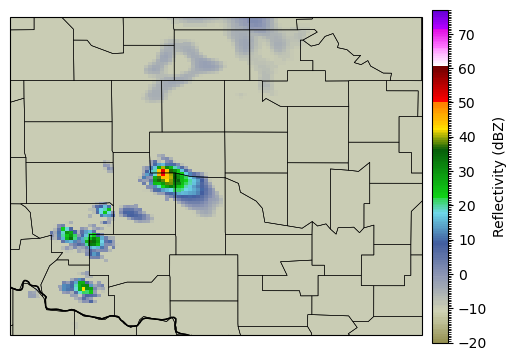

In [12]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_extent((west, east, south, north), crs=ccrs.PlateCarree())
ax.add_feature(USCOUNTIES, linewidth=0.4)
ax.add_feature(cfeature.STATES)

norm, cmap = ctables.registry.get_with_steps('NWSStormClearReflectivity', -20, 0.5)

pm = ax.pcolormesh(lon, lat, refl, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

cbar = plt.colorbar(pm, ax=ax, pad=0.02, shrink=0.9)
cbar.set_label('Reflectivity (dBZ)')